#### Notes:
*- Similar to Perceptron and Adaline, Logistic Regression (LR) is also a linear classificatin method.* \
*- LR can be generalized to multiclass settings: Multinomial LR or softmax regression* \
*- Sigmoid function: sigmoid(z) = 1 / (1 + exp(-z))*

#### Sigmoid curve:
<!-- ![images](./images/sigmoid_curve.png) -->
<img src="./images/sigmoid_curve.png" width=300>

#### Adaline vs LR: use sigmoid function before threshold function.
<img src="./images/adaline_vs_lr.png" width=500> >

#### Theory
- Define a Likelihood function -> the pmf of Bernoulli function: $\mathcal{L}(w,b|x)$ = p(y|x,w,b) = $\prod_{i=1}^n$(p_i) = Bernoulli(y|sigmoid(w.x + b)) \
<img src="./images/likelihood_function.png" width=500>
- The trick here is that: if sigmoid(z) = 0.1 -> p(y=0|w,b) = 0.9 and p(y=1|w,b)=0.1
- The Bernoulli trick is just a convert function to compute the probability for the target class from the Likelihood function.
- Define a Log-Likelihood function: $\mathcal{l}(w,b|x)$ = log($\mathcal{L}(w,b|x)$ ) \
<img src="./images/log_likelihood_function.png" width=500>
- For the algos to work, we want to maximize the log-likelihood function -> minimize the negative log-likelihood function.
- So, we set the Loss function to the negative-log-likelihood function -> use GD to find out the best w, b. \
<img src="./images/loss_function_LogisticR.png" width=500>
<img src="./images/loss_function_Logistic_indicator.png" width=500>
<img src="./images/logistic_regression_loss_viz.png" width=500>


#### GD for the Loss function
- Use the chain rule to compute the derivative of the Loss over weight and bias. The outcome is similar to the GD of MSE for updating the weight and bias.
- The reason to use GD for this Loss function is because it's convex.
- Convex because it's a Bernoulli function? not quite, because it's Bernoulli of probability (a in the formula), and not over weights and bias. To prove it, we must prove the Hessian (second order derivative of the Loss) is greater than 0. The Hessian is computed based on this first derivative, and the outcome is a(1-a)x^2 >= 0 or x^2.exp(-wx)/(1+exp(-wx)) \
<img src="./images/lr_loss_derivative.png" width=500>

In [3]:
# import libraries
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [4]:
# load dataset
iris = load_iris()
features = iris.data
labels = iris.target

print(iris.target_names)
print(iris.feature_names)

['setosa' 'versicolor' 'virginica']
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


In [5]:
# get a subset for training
X = features[(labels == 0) | (labels == 1)]
y = labels[(labels == 0) | (labels == 1)]

# scale the dataset
scaler = StandardScaler()
X_std = scaler.fit_transform(X)

np.bincount(y)

array([50, 50])

In [6]:
# get the vanilla LR
from classification_algos.logistic_regression import LogisticRegression
vanilla_lr = LogisticRegression(n_iter=100, lr=0.05)

vanilla_lr.fit(X_std, y)
preds = vanilla_lr.predict(X_std)

accuracy = accuracy_score(preds, y)
print(accuracy)

0.99


#### Sklearn Logistic Regression

In [7]:
# get the model
from sklearn.linear_model import LogisticRegression
log_reg = LogisticRegression()

In [9]:
# split dataset
X_train, X_test, y_train, y_test = train_test_split(features, labels, test_size=0.2, shuffle=True, stratify=labels, random_state=8)
print(np.bincount(y_train))
print(np.bincount(y_test))


[40 40 40]
[10 10 10]


In [51]:
# scale the dataset
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [48]:
# train the model:
log_reg.fit(X_train_scaled, y_train)
preds = log_reg.predict(X_test_scaled)
accuracy = accuracy_score(preds, y_test)
print(accuracy)

0.9333333333333333


In [49]:
proba_preds = log_reg.predict_proba(X_test_scaled)
print(proba_preds[:20], y_test[:20])

[[2.68331191e-03 5.61622104e-01 4.35694584e-01]
 [6.49415255e-01 3.50571485e-01 1.32601270e-05]
 [9.43138462e-01 5.68606092e-02 9.28512413e-07]
 [6.90368925e-04 1.98107186e-01 8.01202445e-01]
 [1.45265411e-06 1.05659594e-02 9.89432588e-01]
 [7.05900798e-03 7.25882855e-01 2.67058137e-01]
 [8.90648687e-05 4.71906729e-02 9.52720262e-01]
 [9.83171542e-01 1.68283000e-02 1.57761774e-07]
 [3.59689082e-05 3.12953109e-02 9.68668720e-01]
 [1.71328411e-03 4.12456945e-01 5.85829771e-01]
 [9.81646292e-03 8.42296148e-01 1.47887389e-01]
 [2.46800410e-04 4.39024806e-02 9.55850719e-01]
 [1.39330459e-03 1.75732383e-01 8.22874313e-01]
 [3.54957735e-03 7.02013600e-01 2.94436823e-01]
 [8.60084484e-02 8.58152952e-01 5.58385999e-02]
 [9.83679925e-01 1.63198690e-02 2.06489215e-07]
 [3.60744305e-02 8.92033412e-01 7.18921572e-02]
 [9.70979751e-02 8.93873306e-01 9.02871847e-03]
 [1.43524046e-03 8.21368990e-01 1.77195770e-01]
 [3.23375938e-05 1.92934131e-02 9.80674249e-01]] [2 0 0 2 2 1 2 0 2 1 1 2 2 1 1 0 1 1 1 

In [25]:
print(np.argmax(proba_preds[:30], axis=1) == y_test[:30])

[False  True  True  True  True  True  True  True  True False  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True]


In [39]:
wrong_point_X = X_test[(np.argmax(proba_preds[:30], axis=1) != y_test[:30])]
wrong_point_y = y_test[(np.argmax(proba_preds[:30], axis=1) != y_test[:30])]

print(X_test[(np.argmax(proba_preds[:30], axis=1) != y_test[:30])])
print(y_test[(np.argmax(proba_preds[:30], axis=1) != y_test[:30])])

[[6.3 2.8 5.1 1.5]
 [6.7 3.  5.  1.7]]
[2 1]


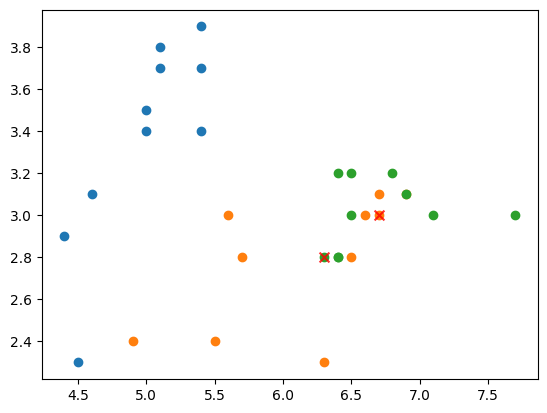

In [61]:
plt.scatter(X_test[y_test==0][:,0], X_test[y_test==0][:,1])
plt.scatter(X_test[y_test==1][:,0], X_test[y_test==1][:,1])
plt.scatter(X_test[y_test==2][:,0], X_test[y_test==2][:,1])
plt.scatter(wrong_point_X[:, 0], wrong_point_X[:, 1], color='red', marker='x', alpha=0.8, s=50)